In [2]:
import openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import BorderlineSMOTE


###  Učitavanje skupa podataka OpenML platforme (ID 1161)

In [3]:
dataset = openml.datasets.get_dataset(1161)
X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format='dataframe',
    target=dataset.default_target_attribute
)

df = pd.DataFrame(X, columns=X.columns)
df['target'] = y.values
df.to_csv('data/data_raw.csv', index=False)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nImamo mnogo više gena (>10^4) nego uzoraka (>10^3) — prokletstvo dimenzionalnosti')

X shape: (1545, 10935)
y shape: (1545,)

Imamo mnogo više gena (>10^4) nego uzoraka (>10^3) — prokletstvo dimenzionalnosti


### Analiziramo distribuciju klasa

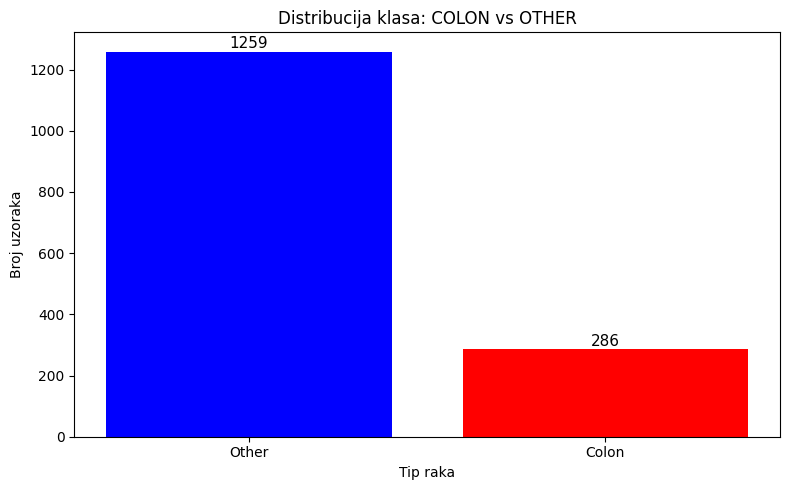

In [15]:
class_counts = y.value_counts()
labels = class_counts.index.tolist()  # labels daje ['Colon', 'Other']
values = class_counts.values.tolist() # values daje broj koliko cega

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['blue', 'red'])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.001,
            str(val), ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Tip raka')
ax.set_ylabel('Broj uzoraka')
ax.set_title('Distribucija klasa: COLON vs OTHER')
plt.tight_layout()
plt.show()

In [17]:
print('Nebalansiran skup podataka:')
imbalance_ratio = class_counts['Other'] / class_counts['Colon']
print(f'  ratio OTHER:COLON = {imbalance_ratio:.2f}:1')
print(f'  Procenat COLON: {class_counts["Colon"]/len(y)*100:.1f}%')
print(f'  Procenat OTHER: {class_counts["Other"]/len(y)*100:.1f}%')


Nebalansiran skup podataka:
  ratio OTHER:COLON = 4.40:1
  Procenat COLON: 18.5%
  Procenat OTHER: 81.5%


### Provera nedostajucih vrednosti

In [18]:
print('Skeniranje nedostajućih vrednosti:')
print(f'  X - ima li NaN: {X.isna().any().any()}')
print(f'  y - ima li NaN: {y.isna().any().any()}')

Skeniranje nedostajućih vrednosti:
  X - ima li NaN: False
  y - ima li NaN: False


### Detekcija autlajera. Za prvih 100 gena racunamo binarnu mapu autlajera (po IQR pravilu) i prikazujemo je kao heat-mapu. Zatim za 5 gena sa **najvecom varijansom** crtamo box-plot

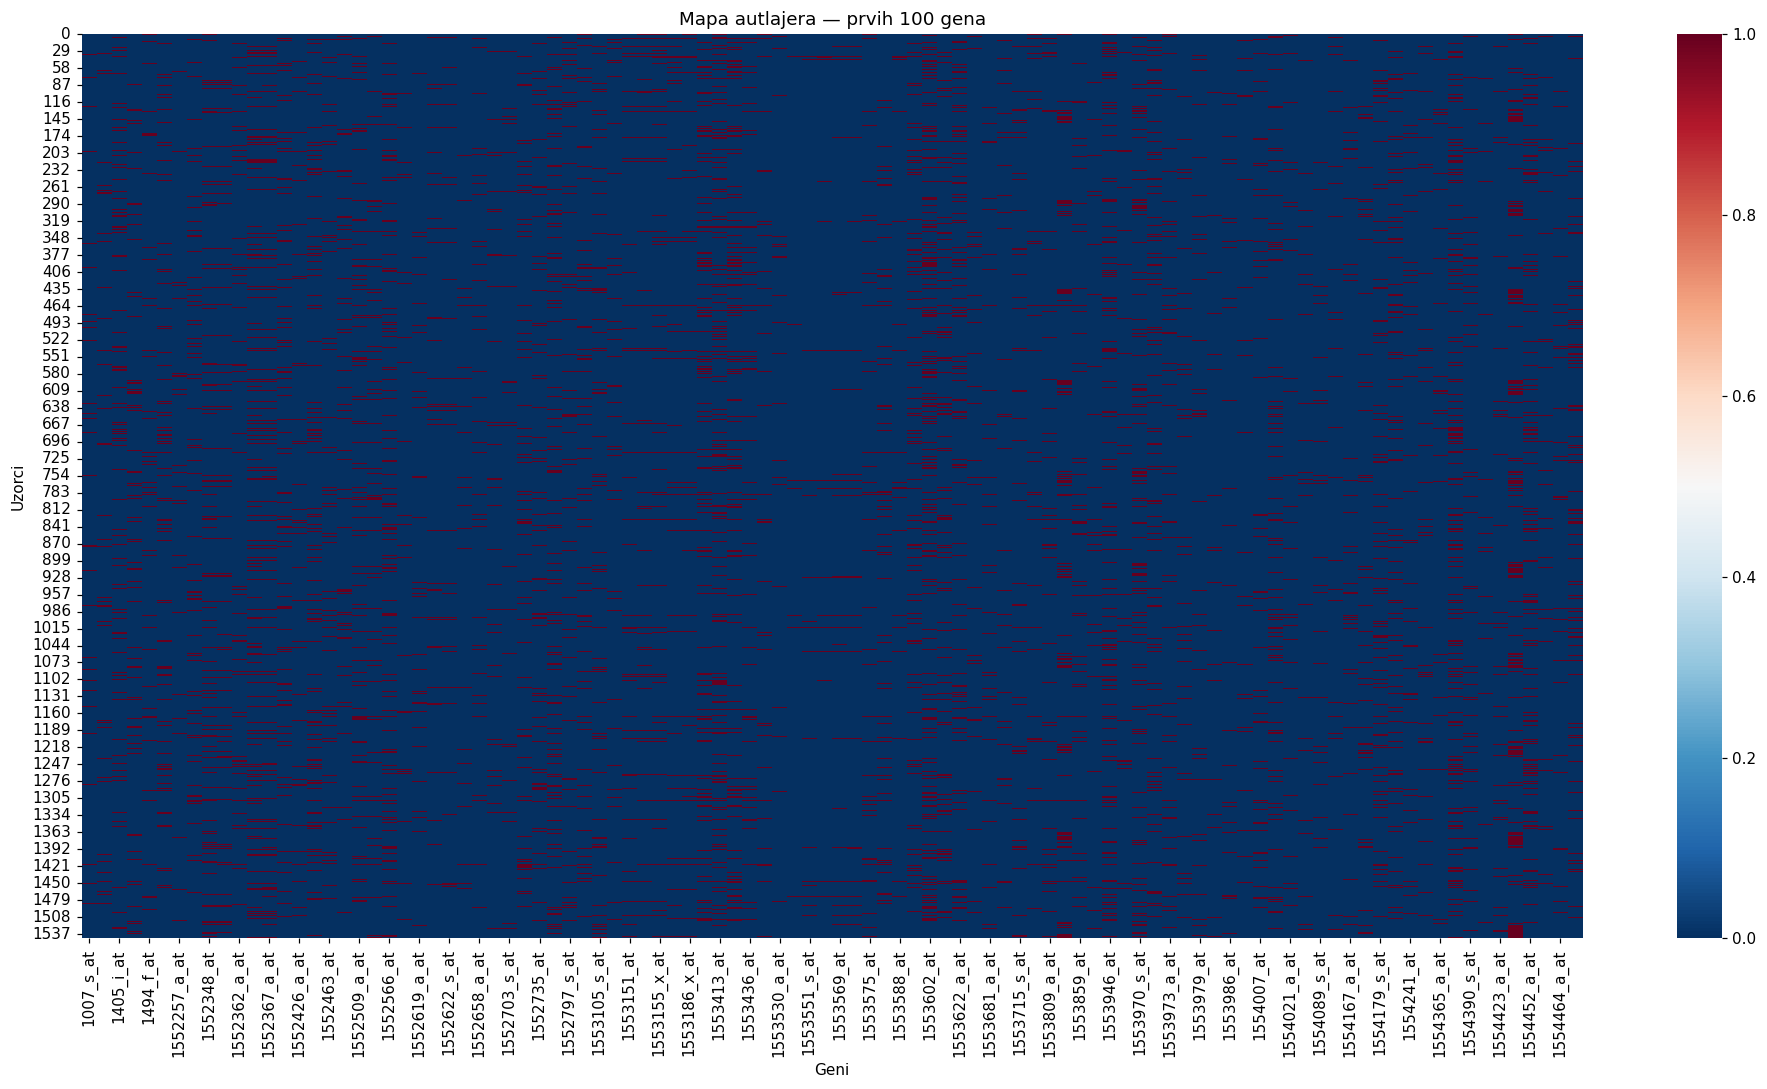

In [51]:
outlier_matrix = pd.DataFrame(index=X.index, columns=X.columns[:100])

for col in X.columns[:100]:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_matrix[col] = ((X[col] < lower_bound) | (X[col] > upper_bound)).astype(int)

plt.figure(figsize=(18, 10))
sns.heatmap(outlier_matrix, cmap='RdBu_r')
plt.title('Mapa autlajera — prvih 100 gena')
plt.xlabel('Geni')
plt.ylabel('Uzorci')
plt.tight_layout()
plt.show()

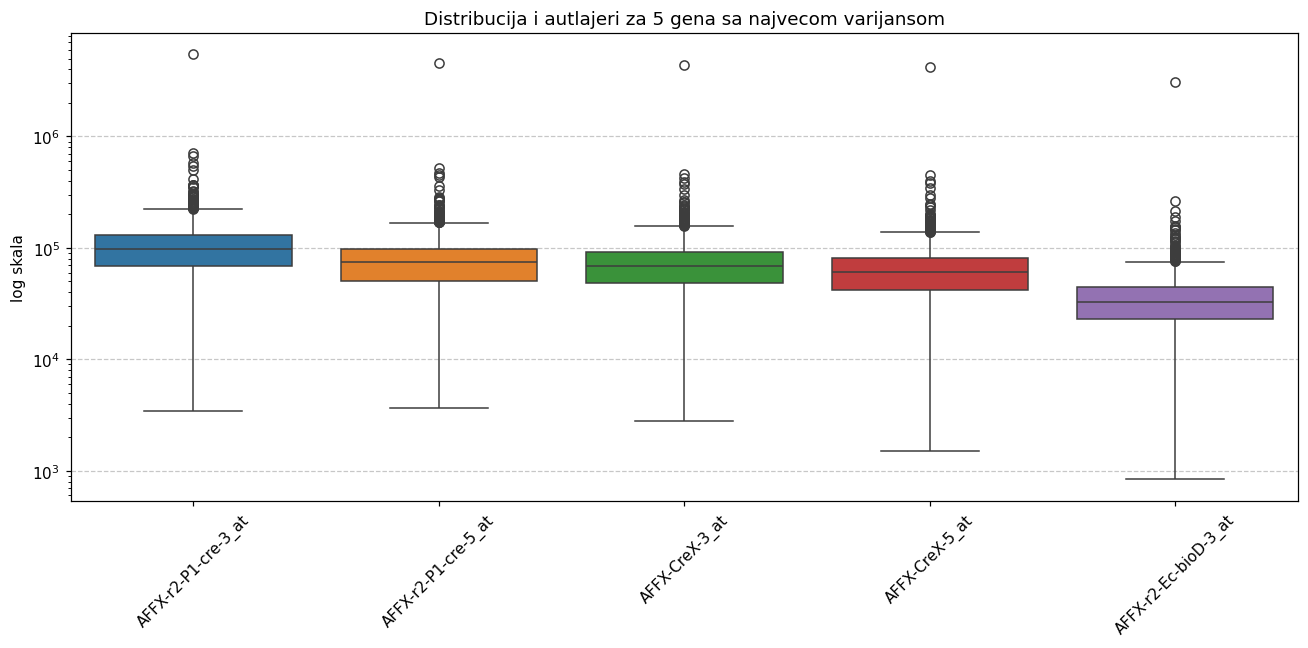

In [52]:
variances = np.var(X, axis=0)
sorted_indices = np.argsort(variances)[::-1]
top_var_genes = sorted_indices[:5]

plt.figure(figsize=(12, 6))
sns.boxplot(data=X.iloc[:, top_var_genes])
plt.title('Distribucija i autlajeri za 5 gena sa najvecom varijansom')
plt.ylabel('log skala')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Standardizacija podataka

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['target'] = y.values
df_scaled.to_csv('data/data_scaled.csv', index=False)

print('Sacuvano: data/data_scaled.csv')

Sacuvano: data/data_scaled.csv


### PCA - gradi nove ortogonalne komponente sortirane po varijansi

Komponente za 70% varijanse: 137
Komponente za 80% varijanse: 278


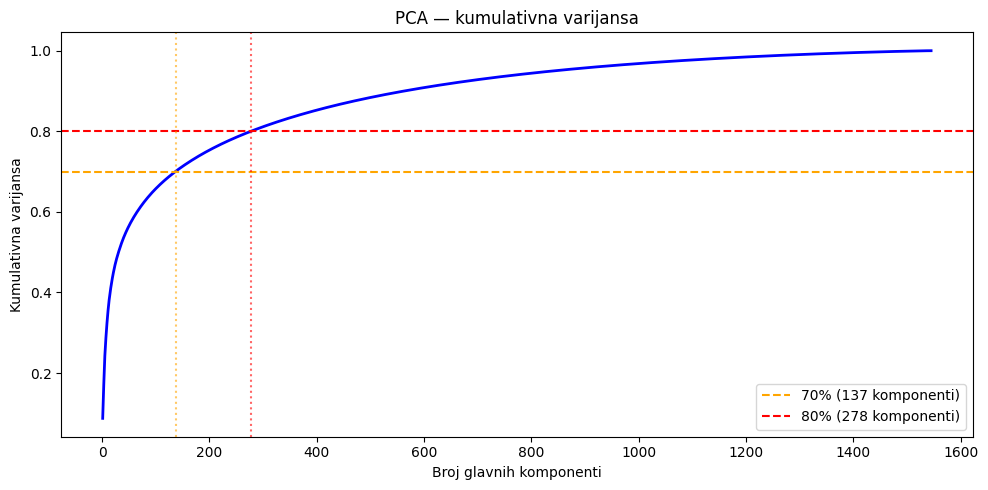

In [22]:
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_70 = int(np.argmax(cumulative_variance >= 0.70)) + 1
n_80 = int(np.argmax(cumulative_variance >= 0.80)) + 1
print(f'Komponente za 70% varijanse: {n_70}')
print(f'Komponente za 80% varijanse: {n_80}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
ax.axhline(y=0.70, color='orange', linestyle='--', label=f'70% ({n_70} komponenti)')
ax.axhline(y=0.80, color='red', linestyle='--', label=f'80% ({n_80} komponenti)')
ax.axvline(x=n_70, color='orange', linestyle=':', alpha=0.6)
ax.axvline(x=n_80, color='red', linestyle=':', alpha=0.6)
ax.set_xlabel('Broj glavnih komponenti')
ax.set_ylabel('Kumulativna varijansa')
ax.set_title('PCA — kumulativna varijansa')
ax.legend()
plt.tight_layout()
plt.show()

###  PCA — 2D vizuelizacija. Tacke su obojene prema klasi: crveno = ***Colon***, plavo = ***Other***

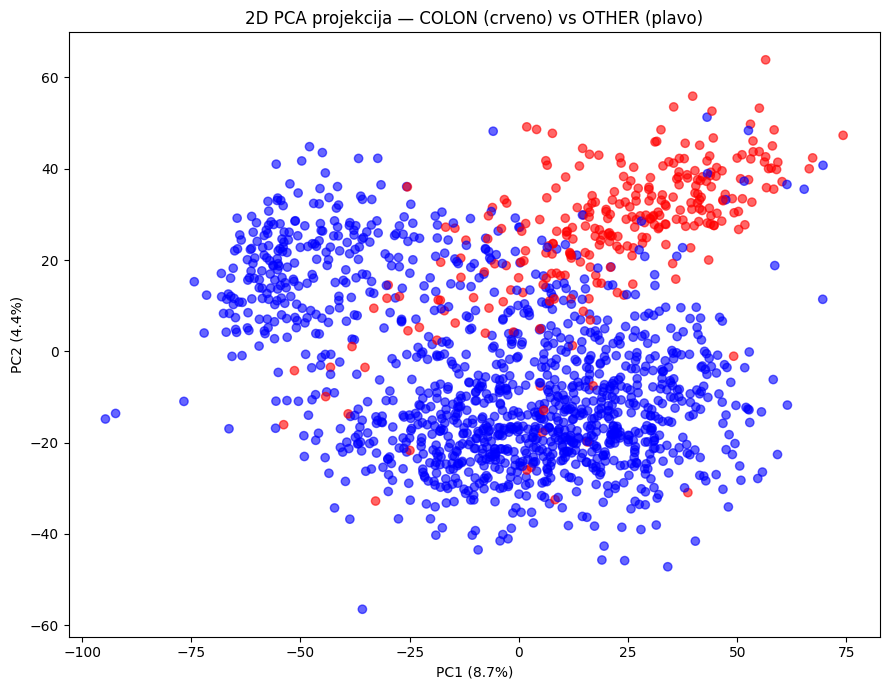

In [27]:
def pca_transform_graph(X, y, components, graph=True):
    pca = PCA(n_components=components)
    X_pca = pca.fit_transform(X)
    colors = ['red' if label == 'Colon' else 'blue' for label in y]

    if graph:
        if components == 2:
            plt.figure(figsize=(9, 7))
            plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6)
            plt.title('2D PCA projekcija — COLON (crveno) vs OTHER (plavo)')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            plt.tight_layout()
            plt.show()
        elif components == 3:
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6)
            ax.set_title('3D PCA projekcija — COLON (crveno) vs OTHER (plavo)')
            ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
            plt.tight_layout()
            plt.show()
    return X_pca, y, pca

X_pca2d, _, _ = pca_transform_graph(X_scaled, y, 2)

### PCA - 3D vizuelizacija

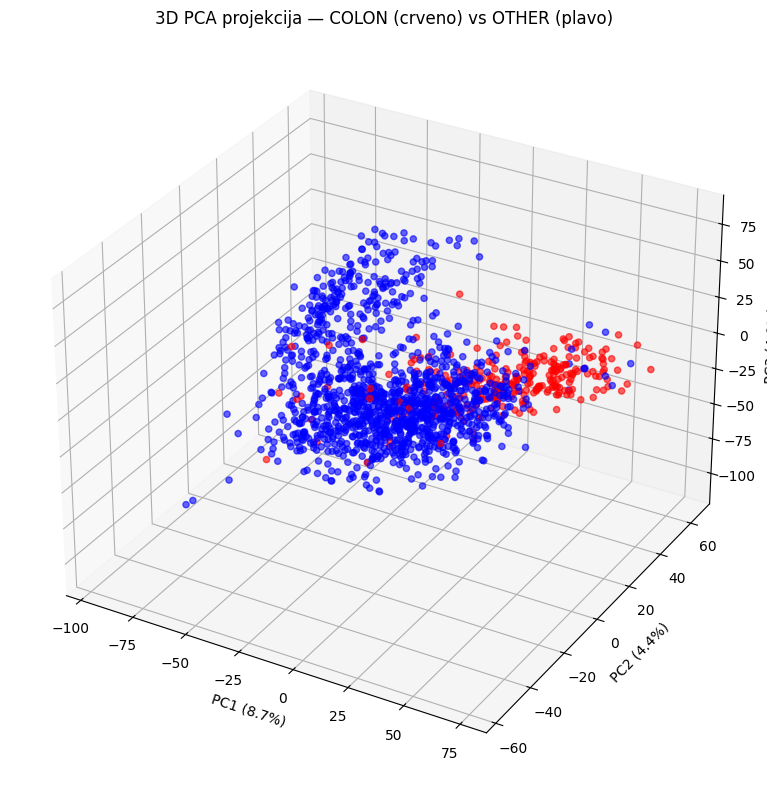


    Klasa Colon formira relativno kompaktan klaster, dok je klasa Other disperznija
    i sastoji se od vise podgrupa. postoji i odredjeni
    stepen separabilnosti 


In [28]:
X_pca3d, _, _ = pca_transform_graph(X_scaled, y, 3)

print('''
    Klasa Colon formira relativno kompaktan klaster, dok je klasa Other disperznija
    i sastoji se od vise podgrupa. postoji i odredjeni
    stepen separabilnosti '''
     )

### t-SNE projekcija je nelinearna tehnika redukcije koja čuva lokalnu strukturu

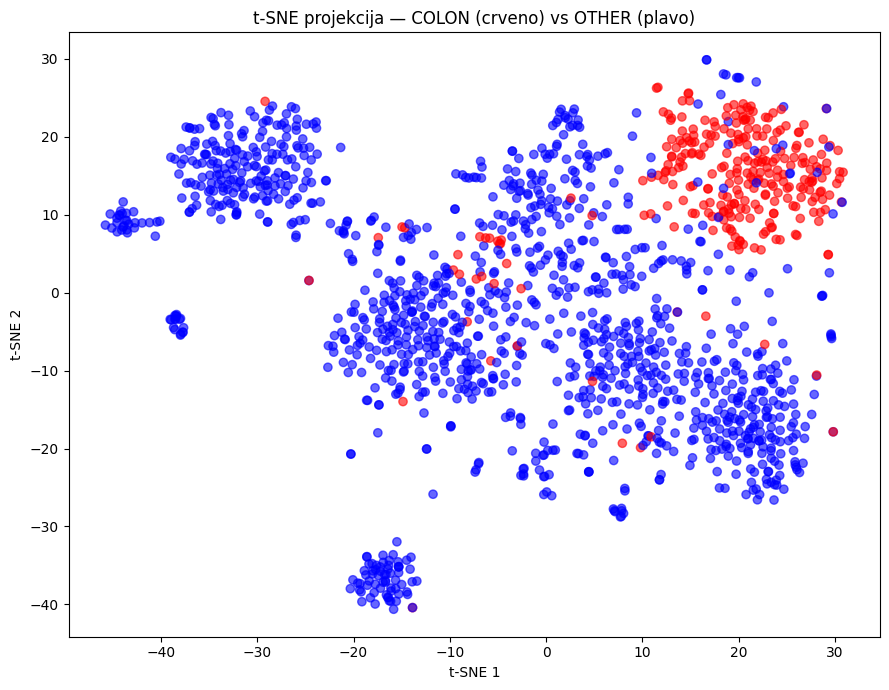


    t-SNE projekcija ne pokazuje znatno bolje razdvajanje klasa od PCA, što znači
    da podaci nemaju izrazenu nelinearnu strukturu i da se klase delimično preklapaju.


In [30]:
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)

colors = ['red' if label == 'Colon' else 'blue' for label in y]
plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6)
plt.title('t-SNE projekcija — COLON (crveno) vs OTHER (plavo)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

print('''
    t-SNE projekcija ne pokazuje znatno bolje razdvajanje klasa od PCA, što znači
    da podaci nemaju izrazenu nelinearnu strukturu i da se klase delimično preklapaju.'''
     )

### Selekcija atributa - `SelectKBest` (F-test)

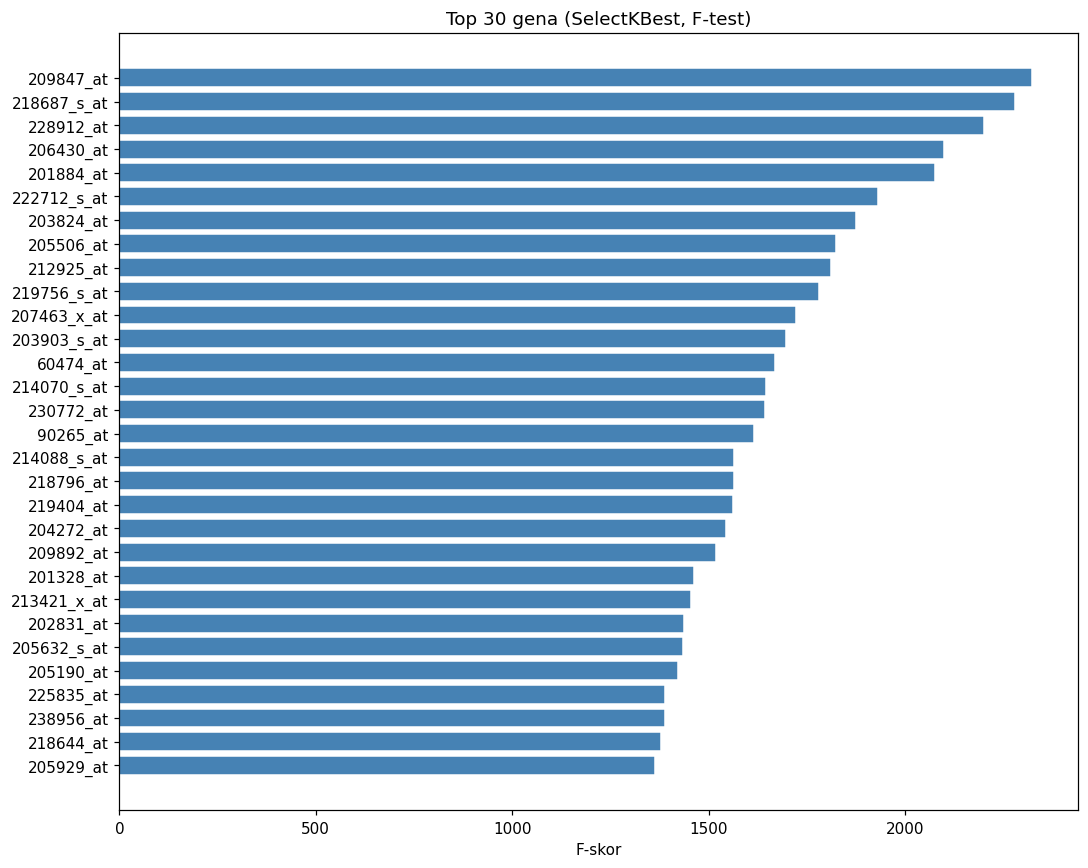

In [58]:
selector = SelectKBest(score_func=f_classif, k=30)
selector.fit(X_scaled, y)

scores = selector.scores_
top_idx = np.argsort(scores)[-30:]
top_features = X.columns[top_idx]
top_scores = scores[top_idx]

sorted_idx = np.argsort(top_scores)
top_features = top_features[sorted_idx]
top_scores = top_scores[sorted_idx]

plt.figure(figsize=(10, 8))
plt.barh(top_features, top_scores, color='steelblue', edgecolor='white')
plt.xlabel('F-skor')
plt.title('Top 30 gena (SelectKBest, F-test)')
plt.tight_layout()
plt.show()

### Korelaciona matrica top gena

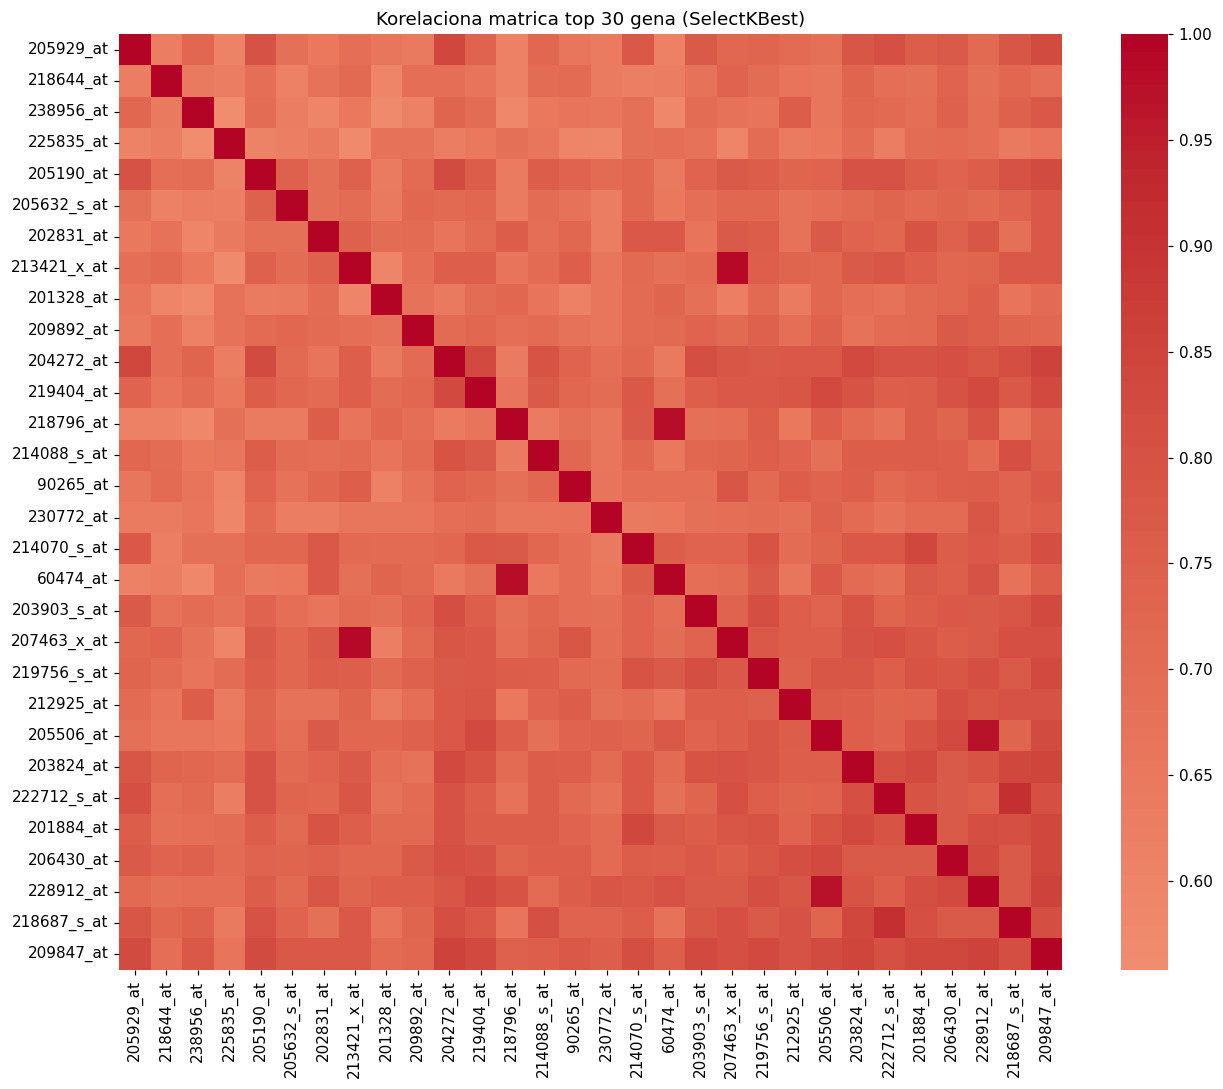

In [59]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.DataFrame(X_scaled, columns=X.columns)[top_features].corr(),
    annot=False, cmap='coolwarm', center=0
)
plt.title('Korelaciona matrica top 30 gena (SelectKBest)')
plt.tight_layout()
plt.show()

### SMOTE (bordered) oversampling

In [60]:
def smote(X, y, save=False, filename=''):
    sm = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=3)
    X_res, y_res = sm.fit_resample(X, y)
    if save:
        df = pd.DataFrame(X_res)
        df['target'] = y_res.values
        df.to_csv(filename, index=False)
        print(f'  Sačuvano: {filename}  shape={X_res.shape}')
        return
    return X_res, y_res

smote(X_scaled, y, save=True, filename='data/data_smote.csv')

  Sačuvano: data/data_smote.csv  shape=(2518, 10935)


###  Generisanje top-K skupova za SMOTE. Generisacemo skup koji sadrzi samo top-K najinformativnijih gena (po F-testu) i nakon toga primenjujemo SMOTE.

In [61]:
def featureselect_smote_save(X, y, k, filename):
    selector = SelectKBest(f_classif, k=k)
    X_selected = selector.fit_transform(X, y)
    selected_cols = X.columns[selector.get_support()]

    sm = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=5)
    X_selected, y_res = sm.fit_resample(X_selected, y)
    print(f'  k={k:>3}: shape={X_selected.shape}, sačuvano u {filename}')

    df = pd.DataFrame(X_selected, columns=selected_cols)
    df['target'] = y_res.values
    df.to_csv(filename, index=False)


print('Generisanje top-K skupova sa SMOTE...')
for k in [20, 30, 40, 50, 100, 200]:
    featureselect_smote_save(X, y, k, f'data/data_top{k}_genes_smote.csv')

Generisanje top-K skupova sa SMOTE...
  k= 20: shape=(2518, 20), sačuvano u data/data_top20_genes_smote.csv
  k= 30: shape=(2518, 30), sačuvano u data/data_top30_genes_smote.csv
  k= 40: shape=(2518, 40), sačuvano u data/data_top40_genes_smote.csv
  k= 50: shape=(2518, 50), sačuvano u data/data_top50_genes_smote.csv
  k=100: shape=(2518, 100), sačuvano u data/data_top100_genes_smote.csv
  k=200: shape=(2518, 200), sačuvano u data/data_top200_genes_smote.csv


### Generisanje PCA skupova (sa i bez SMOTE)

In [62]:
def pca_smote(X, y, components=None, variance_threshold=0.8, smote_flag=True):
    if components is None:
        pca_temp = PCA().fit(X)
        cumvar = np.cumsum(pca_temp.explained_variance_ratio_)
        components = int(np.where(cumvar >= variance_threshold)[0][0]) + 1
        print(f'Izabrano {components} komponenti za {variance_threshold*100:.0f}% varijanse')

    pca = PCA(n_components=components)
    X_pca = pca.fit_transform(X)
    print(f' Varijansa: {sum(pca.explained_variance_ratio_)*100:.1f}%')

    if smote_flag:
        sm = BorderlineSMOTE(random_state=42, kind='borderline-1')
        X_pca, y = sm.fit_resample(X_pca, y)

    return X_pca, y


def save_pca_data(X, y, filename):
    pca_columns = [f'PC{i+1}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=pca_columns)
    df['target'] = y.values if hasattr(y, 'values') else y
    df.to_csv(filename, index=False)
    print(f'  Sacuvano: {filename}  shape={X.shape}')

In [63]:
print('PCA 70% bez SMOTE:')
X_pca70, y_pca70 = pca_smote(X_scaled, y, variance_threshold=0.7, smote_flag=False)
save_pca_data(X_pca70, y_pca70, 'data/data_pca70.csv')

print('\nPCA 80% bez SMOTE:')
X_pca80, y_pca80 = pca_smote(X_scaled, y, variance_threshold=0.8, smote_flag=False)
save_pca_data(X_pca80, y_pca80, 'data/data_pca80.csv')

print('\nPCA 70% + SMOTE:')
X_pca70s, y_pca70s = pca_smote(X_scaled, y, variance_threshold=0.7, smote_flag=True)
save_pca_data(X_pca70s, y_pca70s, 'data/data_pca70_smoted.csv')

print('\nPCA 80% + SMOTE:')
X_pca80s, y_pca80s = pca_smote(X_scaled, y, variance_threshold=0.8, smote_flag=True)
save_pca_data(X_pca80s, y_pca80s, 'data/data_pca80_smoted.csv')

PCA 70% bez SMOTE:
Izabrano 137 komponenti za 70% varijanse
 Varijansa: 70.0%
  Sacuvano: data/data_pca70.csv  shape=(1545, 137)

PCA 80% bez SMOTE:
Izabrano 278 komponenti za 80% varijanse
 Varijansa: 79.8%
  Sacuvano: data/data_pca80.csv  shape=(1545, 278)

PCA 70% + SMOTE:
Izabrano 137 komponenti za 70% varijanse
 Varijansa: 70.0%
  Sacuvano: data/data_pca70_smoted.csv  shape=(2518, 137)

PCA 80% + SMOTE:
Izabrano 278 komponenti za 80% varijanse
 Varijansa: 79.8%
  Sacuvano: data/data_pca80_smoted.csv  shape=(2518, 278)


## Rezime

In [64]:
print('=== REZIME PRIPREME ===')
print(f'Sirov skup:                {X.shape}')
print(f'Klase:                     {dict(class_counts)}')
print(f'Nebalansiranost:           {imbalance_ratio:.2f}:1')
print(f'PCA komponenti (70%):      {n_70}')
print(f'PCA komponenti (80%):      {n_80}')
print()
print('Sacuvani fajlovi u data/:')
import os
for f in sorted(os.listdir('data')):
    if f.endswith('.csv'):
        size_mb = os.path.getsize(f'data/{f}') / 1e6
        print(f'  {f:<40} ({size_mb:>7.2f} MB)')

=== REZIME PRIPREME ===
Sirov skup:                (1545, 10935)
Klase:                     {'Other': np.int64(1259), 'Colon': np.int64(286)}
Nebalansiranost:           4.40:1
PCA komponenti (70%):      137
PCA komponenti (80%):      278

Sacuvani fajlovi u data/:
  data_pca70.csv                           (   4.05 MB)
  data_pca70_smoted.csv                    (   6.61 MB)
  data_pca80.csv                           (   8.26 MB)
  data_pca80_smoted.csv                    (  13.48 MB)
  data_raw.csv                             ( 111.66 MB)
  data_scaled.csv                          ( 336.32 MB)
  data_smote.csv                           ( 548.73 MB)
  data_top100_genes_smote.csv              (   2.76 MB)
  data_top200_genes_smote.csv              (   5.53 MB)
  data_top20_genes_smote.csv               (   0.56 MB)
  data_top30_genes_smote.csv               (   0.83 MB)
  data_top40_genes_smote.csv               (   1.11 MB)
  data_top50_genes_smote.csv               (   1.38 MB)
